### **Quiz 3 - Clustering**

---
#### **Problema**

Se tiene un dataset que contiene la información de 60 clientes.

* **ID**
* **Ingresos**: MXN Mensuales.
* **Edad**: Años.
* **Gasto**: MXN Gastados.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
df = pd.read_excel('./resources/Quiz03_data.xlsx')
df.head()

,Ingresos,Edad,Gasto
0,45000,25,300
1,54000,29,500
2,58000,35,700
3,60000,40,1200
4,52000,23,400


**La empresa X quiere realizar una segentación de clientes utilizando k-means**

#### **Punto 1 (40 puntos)**

Realiza escalimiento de las variables Ingresos, Edad y Gasto.


In [3]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [13]:
#Realiza el código correspondiente
scaled_df = df.copy()

scaled_df['Ingresos'] = scaler.fit_transform(df[['Ingresos']])
scaled_df['Edad'] = scaler.fit_transform(df[['Edad']])
scaled_df['Gasto'] = scaler.fit_transform(df[['Gasto']])

In [10]:
df.head()

,Ingresos,Edad,Gasto
0,45000,25,300
1,54000,29,500
2,58000,35,700
3,60000,40,1200
4,52000,23,400


In [14]:
scaled_df.head()

,Ingresos,Edad,Gasto
0,-1.164040,-1.144197,-1.059280
1,-0.523066,-0.810936,-0.790435
2,-0.238189,-0.311044,-0.521589
3,-0.095750,0.105533,0.150523
4,-0.665505,-1.310828,-0.924857


Responde:
* ¿Qué pasa si no se realiza un escalamiento de los datos? 
Las variables poseen pesos diferentes, por lo que el algoritmo de k-means no podrá encontrar los clusters de manera correcta.

* ¿Cuál es la diferencia entre usar estandarización y normalización?
La normalizacion transforma los datos para que tengan media 0 y desviación estándar 1, mientras que la estandarización transforma los datos para que estén en un rango específico en particular entre el maximo y el minimo de los datos

*Respuestas*

#### **Punto 2 (30 puntos)**

Realiza una grafica de codo y define el número de clusters.

In [5]:
from sklearn.cluster import KMeans

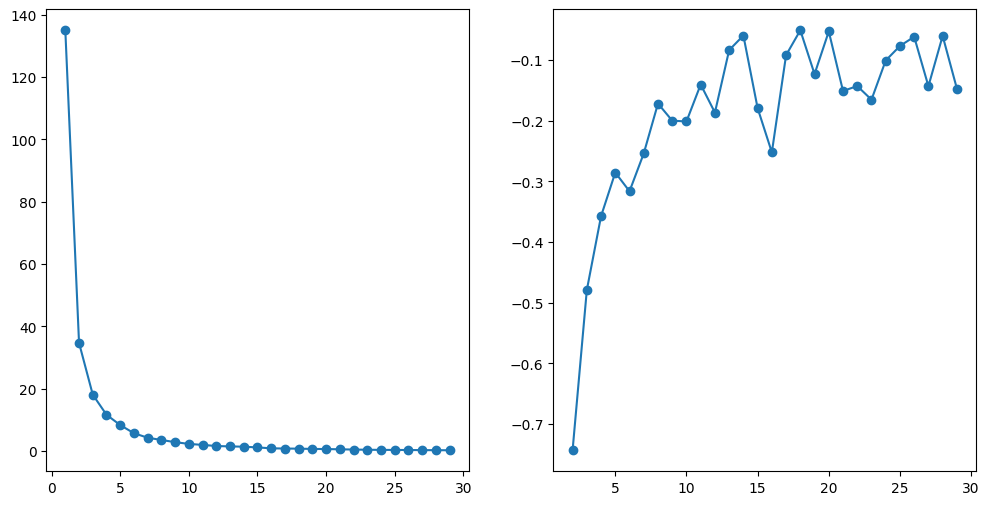

In [15]:
#Realiza el código correspondiente
fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(12, 6))

inertia = []

k_range = range(1, 30)

for k in k_range:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(scaled_df)
    inertia.append(model.inertia_)

inertia_ratio = np.diff(inertia) / np.array(inertia[:-1])

ax2.plot(k_range[1:], inertia_ratio, marker='o')
ax1.plot(k_range, inertia, marker='o')

#ax1.xlabel('Número de clusters')

#ax1.ylabel('Inercia')

#ax1.title('Método del Codo')

plt.show()

jeje no le haga caso a la grafica que no es la del codo

Responde:
* ¿Cuántos grupos de clientes es el óptimo utilizando el método de codo? 3
* Menciona otro método para definir el número de grupos
  * Metodo de la Silueta
  * Conocimiento previo del negocio

#### **Punto 3 (30 puntos)**

- Entrena un modelo de K-means con el número de clusters óptimo.

In [17]:
#Realiza el código correspondiente
Kmeans_model = KMeans(n_clusters=3, random_state=42)

- Asigna el grupo a la base orginal (.fit_predict)

In [18]:
#Realiza el código correspondiente
df['Cluster'] = Kmeans_model.fit_predict(scaled_df)

* Genera un tabla con el numero de clientes por grupo/cluster (group by)

In [19]:
#Realiza el código correspondiente
df.head()

,Ingresos,Edad,Gasto,Cluster
0,45000,25,300,0
1,54000,29,500,0
2,58000,35,700,2
3,60000,40,1200,2
4,52000,23,400,0


In [20]:
df_gropby = df.groupby('Cluster').agg({'Ingresos': ['mean', 'count'], 'Edad': 'mean', 'Gasto': 'mean'}).reset_index()

In [21]:
df_gropby

Cluster Ingresos             Edad        Gasto
              mean count       mean         mean
0       0  47000.0    18  26.333333   362.777778
1       1  78250.0    14  52.857143  2012.857143
2       2  63000.0    13  40.692308  1096.230769